In [ ]:

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Column Creation as the Datset Does not Come With Headers

In [17]:
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

In [18]:
train_path =  "../data/KDDTrain+.txt"
test_path = "../data/KDDTest+.txt"
train_df = pd.read_csv(train_path, names=column_names)
test_df = pd.read_csv(test_path, names=column_names)
print('Train Shape:', train_df.shape)
print('Test Shape:', test_df.shape)
train_df.head()

Train Shape: (125973, 43)
Test Shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [19]:
train_df.info()
train_df.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

duration          0
protocol_type     0
service           0
flag              0
src_bytes         0
dst_bytes         0
land              0
wrong_fragment    0
urgent            0
hot               0
dtype: int64

# Changes labels into binary classes for easier initial classification

In [20]:
train_df = train_df.drop(columns=['difficulty'])
test_df = test_df.drop(columns=['difficulty'])
train_df['label'] = train_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
test_df['label'] = test_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
print(train_df['label'].value_counts())
print(test_df['label'].value_counts())

label
normal    67343
attack    58630
Name: count, dtype: int64
label
attack    12833
normal     9711
Name: count, dtype: int64


# Splits the Code Into Features and Target

In [21]:
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

# Checks which columns are catigorical

In [22]:
categorical_cols = ["protocol_type", "service", "flag"]
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols[:10], "...")

Categorical columns: ['protocol_type', 'service', 'flag']
Numeric columns: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised'] ...


# Encodes target Labels

In [23]:
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print("Target classes:", target_encoder.classes_)
print("Encoded mapping:", {label: idx for idx, label in enumerate(target_encoder.classes_)})

Target classes: ['attack' 'normal']
Encoded mapping: {'attack': 0, 'normal': 1}


# Build Pipelines 

In [24]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

svm_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Baseline Random Forest Model

In [25]:
rf_baseline = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_cv_scores = cross_val_score(
    rf_baseline,
    X_train,
    y_train_encoded,
    cv=cv_strategy,
    scoring="recall",
    n_jobs=-1
)

print("Random Forest baseline CV F1-macro scores:", rf_cv_scores)
print("Random Forest baseline mean CV F1-macro:", np.mean(rf_cv_scores))
print("Random Forest baseline std CV F1-macro:", np.std(rf_cv_scores))


Random Forest baseline CV F1-macro scores: [0.99948029 0.99962878 0.99925755 0.999406   0.99962875]
Random Forest baseline mean CV F1-macro: 0.999480273735972
Random Forest baseline std CV F1-macro: 0.00014086799010956314


# Random Forest random search

In [26]:

rf_param_dist = {
    "classifier__n_estimators": [100, 200, 500],
    "classifier__max_depth": [None, 10, 20, 40],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__bootstrap": [True, False],
    "classifier__class_weight": [None, "balanced", {0: 2, 1: 1}, {0: 3, 1: 1}]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_baseline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="recall",
    cv=cv_strategy,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

rf_random_search.fit(X_train, y_train_encoded)
best_rf_model = rf_random_search.best_estimator_

print("Best Random Forest CV F1-macro:", rf_random_search.best_score_)
print("Best Random Forest parameters:", rf_random_search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END classifier__bootstrap=True, classifier__class_weight={0: 2, 1: 1}, classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=5, classifier__n_estimators=500; total time=  25.0s
[CV] END classifier__bootstrap=True, classifier__class_weight={0: 2, 1: 1}, classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=5, classifier__n_estimators=500; total time=  25.5s
[CV] END classifier__bootstrap=True, classifier__class_weight={0: 2, 1: 1}, classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=5, classifier__n_estimators=500; total time=  27.1s
[CV] END classifier__bootstrap=True, classifier__class_weight={0: 2, 1: 1}, classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=5,

# Test Results of Random Forest

Class order: ['attack', 'normal']
Chosen RF threshold for ATTACK: 0.007
Expected attack precision: 0.90
Expected attack recall:    0.98

Tuned Random Forest Test Results
              precision    recall  f1-score   support

      attack       0.90      0.98      0.94     12833
      normal       0.97      0.85      0.91      9711

    accuracy                           0.93     22544
   macro avg       0.94      0.92      0.92     22544
weighted avg       0.93      0.93      0.93     22544

Confusion Matrix:
[[12620   213]
 [ 1430  8281]]


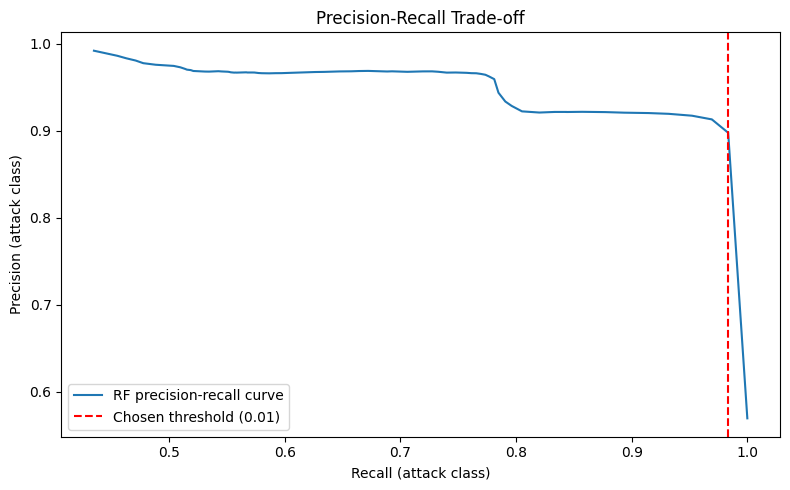

In [27]:
print("Class order:", list(target_encoder.classes_))

attack_label = target_encoder.transform(["attack"])[0]
normal_label = target_encoder.transform(["normal"])[0]

attack_col = list(best_rf_model.classes_).index(attack_label)

y_proba_rf_attack = best_rf_model.predict_proba(X_test)[:, attack_col]

y_test_attack_binary = (y_test_encoded == attack_label).astype(int)

precisions, recalls, thresholds = precision_recall_curve(
    y_test_attack_binary,
    y_proba_rf_attack
)

min_precision_floor = 0.70

valid = precisions[:-1] >= min_precision_floor

if valid.any():
    best_idx = recalls[:-1][valid].argmax()
    best_threshold = thresholds[valid][best_idx]

    chosen_precision = precisions[:-1][valid][best_idx]
    chosen_recall = recalls[:-1][valid][best_idx]

    print(f"Chosen RF threshold for ATTACK: {best_threshold:.3f}")
    print(f"Expected attack precision: {chosen_precision:.2f}")
    print(f"Expected attack recall:    {chosen_recall:.2f}")
else:
    best_threshold = 0.50
    print("No threshold met the minimum precision floor.")
    print("Falling back to threshold = 0.50")

y_pred_tuned = np.where(
    y_proba_rf_attack >= best_threshold,
    attack_label,
    normal_label
)

print("\nTuned Random Forest Test Results")
print(classification_report(
    y_test_encoded,
    y_pred_tuned,
    target_names=target_encoder.classes_
))
print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_tuned))


plt.figure(figsize=(8, 5))
plt.plot(recalls[:-1], precisions[:-1], label="RF precision-recall curve")

if valid.any():
    plt.axvline(
        recalls[:-1][valid][best_idx],
        color='red',
        linestyle='--',
        label=f"Chosen threshold ({best_threshold:.2f})"
    )

plt.xlabel("Recall (attack class)")
plt.ylabel("Precision (attack class)")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_prob_rf = best_rf_model.predict_proba(X_test)[:, 0]  # attack probability

print("ROC-AUC (attack):", roc_auc_score((y_test_encoded == 0).astype(int), y_prob_rf))
print("PR-AUC (attack):", average_precision_score((y_test_encoded == 0).astype(int), y_prob_rf))

ROC-AUC (attack): 0.9603386783200873
PR-AUC (attack): 0.9626879377381388


# SVM baseline model

In [29]:
svm_baseline = Pipeline([
    ("preprocessor", svm_preprocessor),
    ("classifier", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

svm_cv_scores = cross_val_score(
    svm_baseline,
    X_train,
    y_train_encoded,
    cv=cv_strategy,
    scoring="recall",
    n_jobs=-1
)

print("Baseline SVM CV F1-macro scores:", svm_cv_scores)
print("Baseline SVM mean CV F1-macro:", np.mean(svm_cv_scores))
print("Baseline SVM std CV F1-macro:", np.std(svm_cv_scores))


Baseline SVM CV F1-macro scores: [0.99205583 0.99272403 0.98997698 0.99160974 0.99220374]
Baseline SVM mean CV F1-macro: 0.9917140665748579
Baseline SVM std CV F1-macro: 0.0009386113997566542


# SVM randomized search 

In [ ]:
# SVM randomized search with separate validation set for threshold tuning

X_train_svm, X_val_svm, y_train_svm, y_val_svm = train_test_split(
    X_train,
    y_train_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_train_encoded
)

svm_param_dist = {
    "classifier__C": [0.01, 0.1, 1, 10, 50, 100, 500],
    "classifier__gamma": ["scale", "auto", 0.0001, 0.001, 0.01, 0.1],
    "classifier__kernel": ["rbf"],
    "classifier__class_weight": [None, "balanced", {0: 2, 1: 1}, {0: 3, 1: 1}]
}

svm_random_search = RandomizedSearchCV(
    estimator=svm_baseline,
    param_distributions=svm_param_dist,
    n_iter=8,
    scoring="recall",
    cv=cv_strategy,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

svm_random_search.fit(X_train_svm, y_train_svm)

best_svm_model = svm_random_search.best_estimator_

print("Best SVM CV recall:", svm_random_search.best_score_)
print("Best SVM parameters:", svm_random_search.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


[CV] END classifier__C=100, classifier__class_weight={0: 2, 1: 1}, classifier__gamma=0.1, classifier__kernel=rbf; total time= 7.4min
[CV] END classifier__C=100, classifier__class_weight={0: 2, 1: 1}, classifier__gamma=0.1, classifier__kernel=rbf; total time= 7.4min
[CV] END classifier__C=100, classifier__class_weight={0: 2, 1: 1}, classifier__gamma=0.1, classifier__kernel=rbf; total time= 7.8min
[CV] END classifier__C=100, classifier__class_weight={0: 2, 1: 1}, classifier__gamma=0.1, classifier__kernel=rbf; total time= 8.0min
[CV] END classifier__C=100, classifier__class_weight={0: 2, 1: 1}, classifier__gamma=0.1, classifier__kernel=rbf; total time= 8.1min
[CV] END classifier__C=50, classifier__class_weight={0: 3, 1: 1}, classifier__gamma=0.1, classifier__kernel=rbf; total time= 7.9min
[CV] END classifier__C=50, classifier__class_weight={0: 3, 1: 1}, classifier__gamma=0.1, classifier__kernel=rbf; total time= 7.8min
[CV] END classifier__C=50, classifier__class_weight={0: 3, 1: 1}, class

/home/jacobrawlins/ADSProject/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END classifier__C=100, classifier__class_weight={0: 3, 1: 1}, classifier__gamma=0.01, classifier__kernel=rbf; total time= 5.0min
[CV] END classifier__C=100, classifier__class_weight={0: 3, 1: 1}, classifier__gamma=0.01, classifier__kernel=rbf; total time= 4.7min
[CV] END classifier__C=100, classifier__class_weight={0: 3, 1: 1}, classifier__gamma=0.01, classifier__kernel=rbf; total time= 5.1min
[CV] END classifier__C=100, classifier__class_weight={0: 3, 1: 1}, classifier__gamma=0.01, classifier__kernel=rbf; total time= 5.1min
[CV] END classifier__C=0.1, classifier__class_weight=None, classifier__gamma=0.1, classifier__kernel=rbf; total time=11.6min
[CV] END classifier__C=500, classifier__class_weight={0: 2, 1: 1}, classifier__gamma=0.1, classifier__kernel=rbf; total time= 7.2min
[CV] END classifier__C=0.1, classifier__class_weight=balanced, classifier__gamma=scale, classifier__kernel=rbf; total time=40.2min
[CV] END classifier__C=500, classifier__class_weight={0: 2, 1: 1}, classifi

# SVM test results

In [ ]:


print("Class order:", list(target_encoder.classes_))

attack_label = target_encoder.transform(["attack"])[0]
normal_label = target_encoder.transform(["normal"])[0]

attack_col = list(best_svm_model.classes_).index(attack_label)



y_proba_svm_val_attack = best_svm_model.predict_proba(X_val_svm)[:, attack_col]

y_val_svm_attack_binary = (y_val_svm == attack_label).astype(int)

precisions_svm, recalls_svm, thresholds_svm = precision_recall_curve(
    y_val_svm_attack_binary,
    y_proba_svm_val_attack
)

min_precision_floor = 0.70

valid_svm = precisions_svm[:-1] >= min_precision_floor

if valid_svm.any():
    best_idx_svm = recalls_svm[:-1][valid_svm].argmax()

    best_threshold_svm = thresholds_svm[valid_svm][best_idx_svm]

    chosen_precision_svm = precisions_svm[:-1][valid_svm][best_idx_svm]
    chosen_recall_svm = recalls_svm[:-1][valid_svm][best_idx_svm]

    print(f"Chosen SVM threshold for ATTACK: {best_threshold_svm:.3f}")
    print(f"Validation attack precision: {chosen_precision_svm:.2f}")
    print(f"Validation attack recall:    {chosen_recall_svm:.2f}")
else:
    best_threshold_svm = 0.50
    print("No validation threshold met the minimum precision floor.")
    print("Falling back to threshold = 0.50")



y_proba_svm_attack = best_svm_model.predict_proba(X_test)[:, attack_col]

y_pred_svm_tuned = np.where(
    y_proba_svm_attack >= best_threshold_svm,
    attack_label,
    normal_label
)

print("\nTuned SVM Test Results")
print(classification_report(
    y_test_encoded,
    y_pred_svm_tuned,
    target_names=target_encoder.classes_
))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_svm_tuned))

Class order: ['attack', 'normal']
Chosen SVM threshold for ATTACK: 0.000
Expected attack precision: 0.70
Expected attack recall:    1.00

Tuned SVM Test Results
              precision    recall  f1-score   support

      attack       0.70      1.00      0.82     12833
      normal       1.00      0.44      0.61      9711

    accuracy                           0.76     22544
   macro avg       0.85      0.72      0.72     22544
weighted avg       0.83      0.76      0.73     22544

Confusion Matrix:
[[12821    12]
 [ 5462  4249]]


In [32]:
import joblib
import os
os.makedirs("models", exist_ok=True)

joblib.dump(best_rf_model, "models/ids_random_forest_model.pkl")
joblib.dump(target_encoder, "models/label_encoder.pkl")
joblib.dump(X_train.columns.tolist(), "models/feature_columns.pkl")

['models/feature_columns.pkl']